In [56]:
import pandas as pd              
import numpy as np              
import matplotlib.pyplot as plt 
import seaborn as sns            
import pickle                    
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

In [57]:
df = pd.read_csv('urban_water_demand.csv')

In [58]:
print( df.shape[0])



1000


In [59]:
print( df.shape[1])


8


In [60]:
print(df.columns.tolist())

['Household_Size', 'Seasonal_Index', 'Garden_Area', 'Income_Level', 'Building_Type', 'Avg_Temperature_C', 'Num_Appliances', 'Daily_Liters_Used']


In [61]:
print(df.head())

   Household_Size  Seasonal_Index  Garden_Area Income_Level Building_Type  \
0             3.0            0.82        205.1       Medium     Apartment   
1             6.0            1.05          0.0         High     Row_House   
2             4.0            1.27         82.6         High         Villa   
3             4.0            1.18          0.0          Low     Apartment   
4             2.0            1.22        175.8          Low         Villa   

   Avg_Temperature_C  Num_Appliances  Daily_Liters_Used  
0               16.6             9.0             734.05  
1               26.7             3.0            1144.01  
2               33.1             3.0            1294.00  
3               31.7             2.0             626.69  
4               29.4             7.0             823.77  


In [62]:
print(df.dtypes)

Household_Size       float64
Seasonal_Index       float64
Garden_Area          float64
Income_Level             str
Building_Type            str
Avg_Temperature_C    float64
Num_Appliances       float64
Daily_Liters_Used    float64
dtype: object


In [63]:
print(df.isnull().sum())

Household_Size       50
Seasonal_Index       50
Garden_Area          50
Income_Level          0
Building_Type         0
Avg_Temperature_C    50
Num_Appliances       50
Daily_Liters_Used     0
dtype: int64


In [64]:
df['Household_Size']    = df['Household_Size'].fillna(df['Household_Size'].median())
df['Seasonal_Index']    = df['Seasonal_Index'].fillna(df['Seasonal_Index'].mean())
df['Garden_Area']       = df['Garden_Area'].fillna(df['Garden_Area'].median())
df['Avg_Temperature_C'] = df['Avg_Temperature_C'].fillna(df['Avg_Temperature_C'].mean())
df['Num_Appliances']    = df['Num_Appliances'].fillna(df['Num_Appliances'].median())

In [65]:
print(df.isnull().sum())

Household_Size       0
Seasonal_Index       0
Garden_Area          0
Income_Level         0
Building_Type        0
Avg_Temperature_C    0
Num_Appliances       0
Daily_Liters_Used    0
dtype: int64


In [66]:
le1 = LabelEncoder()
le2 = LabelEncoder()
df['Income_Level']  = le1.fit_transform(df['Income_Level'])
df['Building_Type'] = le2.fit_transform(df['Building_Type'])

In [67]:
print(df[['Income_Level', 'Building_Type']].head(5))

   Income_Level  Building_Type
0             2              0
1             0              1
2             0              2
3             1              0
4             1              2


In [68]:
print(df.describe().round(2))

       Household_Size  Seasonal_Index  Garden_Area  Income_Level  \
count         1000.00         1000.00      1000.00       1000.00   
mean             3.27            1.03       113.30          1.22   
std              1.38            0.19        94.64          0.81   
min              1.00            0.70         0.00          0.00   
25%              2.00            0.87        18.60          1.00   
50%              3.00            1.03        98.95          1.00   
75%              4.00            1.18       199.77          2.00   
max              6.00            1.35       299.90          2.00   

       Building_Type  Avg_Temperature_C  Num_Appliances  Daily_Liters_Used  
count        1000.00            1000.00         1000.00            1000.00  
mean            0.74              25.12            5.35             776.35  
std             0.77               6.01            2.31             331.82  
min             0.00               9.30            2.00             107.10  
25

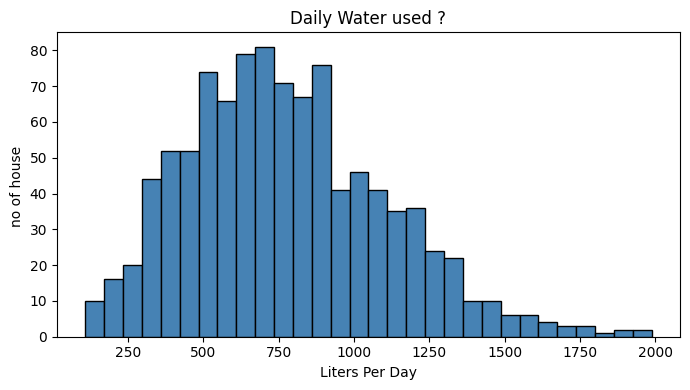

In [69]:
plt.figure(figsize=(7, 4))
plt.hist(df['Daily_Liters_Used'], bins=30, color='steelblue', edgecolor='black')
plt.title('Daily Water used ?')
plt.xlabel('Liters Per Day')
plt.ylabel('no of house ')
plt.tight_layout()
plt.show()

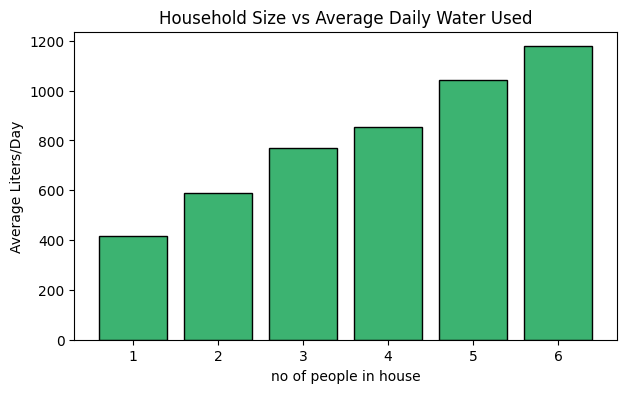

In [70]:
plt.figure(figsize=(7, 4))
hs = df['Household_Size'].round().astype(int)
avg = df.groupby(hs)['Daily_Liters_Used'].mean()
plt.bar([str(x) for x in avg.index], avg.values,
        color='mediumseagreen', edgecolor='black')
plt.title('Household Size vs Average Daily Water Used')
plt.xlabel('no of people in house')
plt.ylabel('Average Liters/Day')
plt.show()

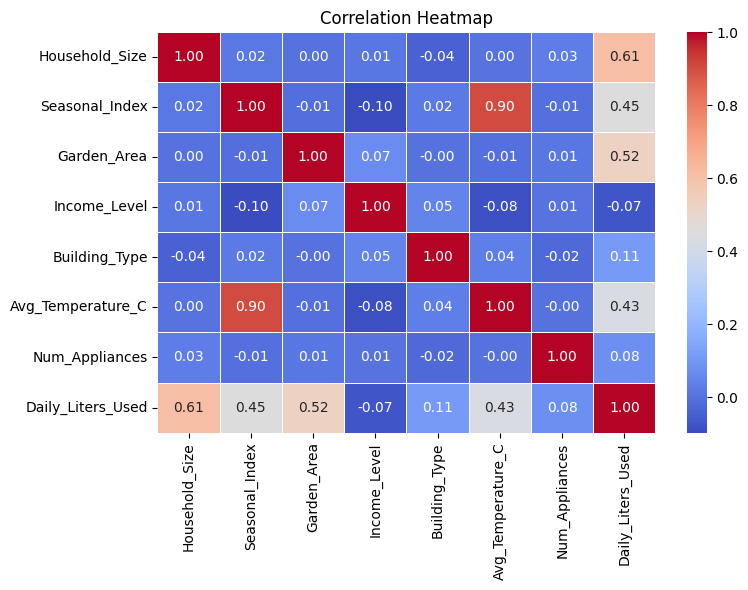

In [71]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


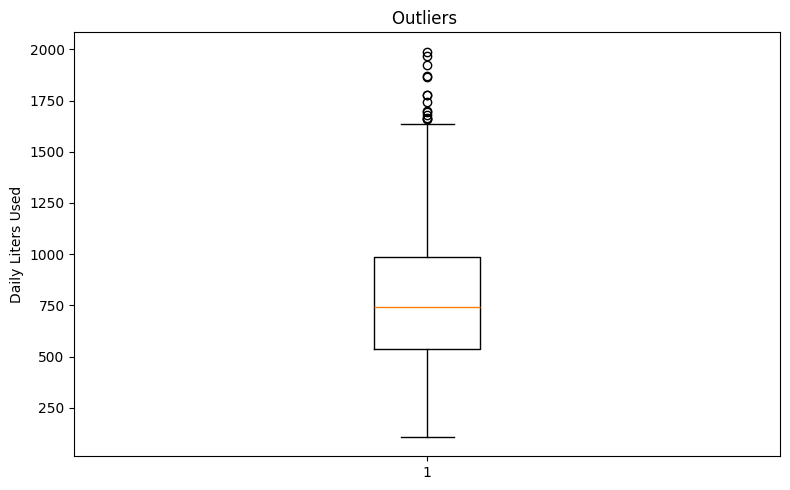

In [72]:
plt.figure(figsize=(8, 5))
bp = plt.boxplot(df['Daily_Liters_Used'])
bp['boxes'][0]
bp['boxes'][0]
q1, q3 = df['Daily_Liters_Used'].quantile([0.25, 0.75])
iqr = q3 - q1
out = int(((df['Daily_Liters_Used'] < q1 - 1.5*iqr) |
           (df['Daily_Liters_Used'] > q3 + 1.5*iqr)).sum())
plt.title(f'Outliers ')
plt.ylabel('Daily Liters Used')
plt.tight_layout()
plt.show()

In [73]:
x = df[['Household_Size', 'Seasonal_Index', 'Garden_Area']]
y = df['Daily_Liters_Used']  

In [74]:
print( x.shape)
print( y.shape)

(1000, 3)
(1000,)


In [75]:
x_train ,x_test,y_train,y_test = tts(x,y,test_size=0.20)

In [76]:
x_train.shape

(800, 3)

In [77]:
x_test.shape

(200, 3)

In [78]:
# Standard scalar 
std_scaler  = StandardScaler()
X_train_std = std_scaler.fit_transform(x_train)  
X_test_std  = std_scaler.transform(x_test)        




In [79]:
#Min Max scalar
mm_scaler  = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(x_train)
X_test_mm  = mm_scaler.transform(x_test)

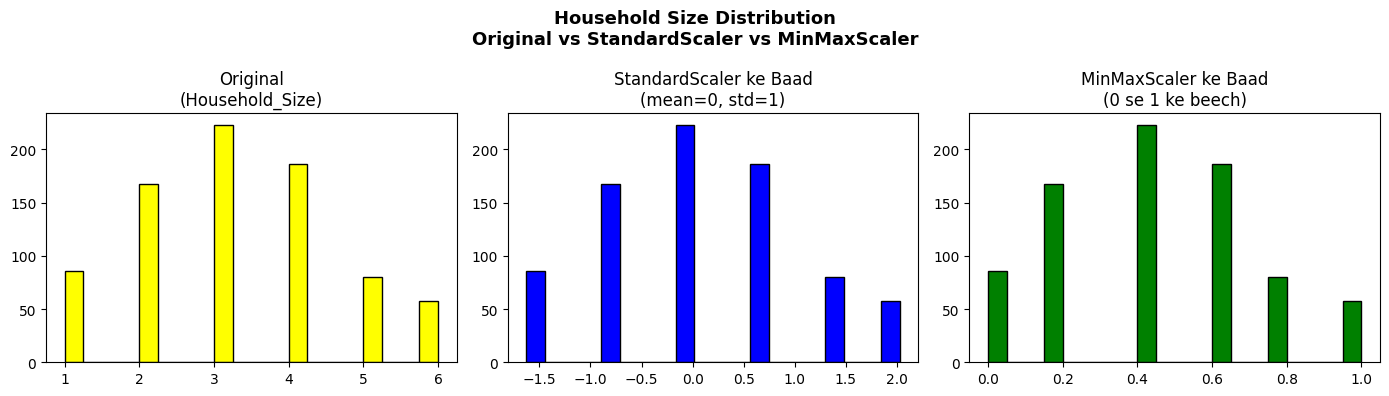

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Household Size Distribution\nOriginal vs StandardScaler vs MinMaxScaler',
             fontsize=13, fontweight='bold')

axes[0].hist(x_train.iloc[:, 0], bins=20, color='yellow', edgecolor='black')
axes[0].set_title('Original\n(Household_Size)')

axes[1].hist(X_train_std[:, 0], bins=20, color='blue', edgecolor='black')
axes[1].set_title('StandardScaler ke Baad\n(mean=0, std=1)')

axes[2].hist(X_train_mm[:, 0], bins=20, color='green', edgecolor='black')
axes[2].set_title('MinMaxScaler ke Baad\n(0 se 1 ke beech)')

plt.tight_layout()
plt.show()

In [81]:
lr = LinearRegression()
lasso = Lasso()
ridge = Ridge()

In [82]:
lr.fit(x_train, y_train) 
lasso.fit(x_train, y_train) 
ridge.fit(x_train, y_train) 


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [83]:
lr_pred = lr.predict(x_test) 
las_predict = lasso.predict(x_test) 
rid_predict = ridge.predict(x_test)

In [84]:
lr_rsccore = r2_score(y_test , lr_pred)
las_rscore = r2_score(y_test , las_predict)
rid_rsccore = r2_score(y_test , rid_predict)

In [85]:
lr_msc = mean_squared_error(y_test , lr_pred)
las_msc = mean_squared_error(y_test , las_predict)
rid_msc = mean_squared_error(y_test , rid_predict)

In [86]:
lr_msc= mean_absolute_error(y_test , lr_pred)
las_msc = mean_absolute_error(y_test , las_predict)
rid_msc = mean_absolute_error(y_test , rid_predict)

In [87]:
print("\nPerformance of liner regretion model")
print("R2score", lr_rsccore)
print("MSE:",lr_msc)
print("MAE:", lr_msc)

print("\nPerformance of Lasso  regretion model")
print("R2score",las_rscore )
print("MSE:",las_msc)
print("MAE:", las_msc)

print("\nPerformance of Ridge regretion model")
print("R2score", rid_rsccore)
print("MSE:",rid_msc)
print("MAE:", rid_msc)




Performance of liner regretion model
R2score 0.8315565855447148
MSE: 101.928984830888
MAE: 101.928984830888

Performance of Lasso  regretion model
R2score 0.8323235897529303
MSE: 101.16029911836304
MAE: 101.16029911836304

Performance of Ridge regretion model
R2score 0.8322903954630537
MSE: 101.1819308336766
MAE: 101.1819308336766


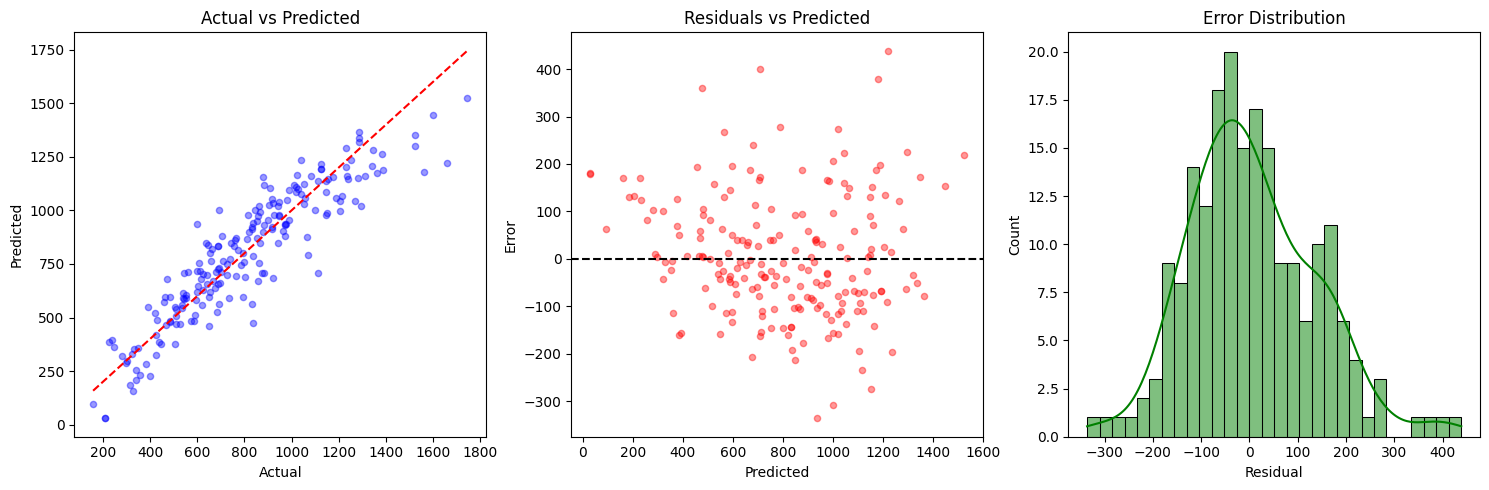

In [88]:
residuals = y_test - lr_pred
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(y_test, lr_pred, alpha=0.4, color='blue', s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title('Actual vs Predicted')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[1].scatter(lr_pred, residuals, alpha=0.4, color='red', s=20)
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Error')
sns.histplot(residuals, kde=True, ax=axes[2], color='green', bins=30)
axes[2].set_title('Error Distribution')
axes[2].set_xlabel('Residual')
plt.tight_layout()
plt.show()

In [89]:
comparison = pd.DataFrame({
    'Actual'   : y_test.values[:10].round(1),
    'Predicted': lr_pred[:10].round(1),
    'Error'    : (y_test.values[:10] - lr_pred[:10]).round(1)
})
print(comparison)

   Actual  Predicted  Error
0   853.4      871.4  -18.0
1  1053.8     1123.3  -69.5
2   837.0      785.8   51.2
3   759.9      861.4 -101.4
4   860.0     1018.9 -158.9
5  1233.4     1161.6   71.8
6   470.8      678.4 -207.6
7   737.6      774.3  -36.7
8  1744.5     1525.9  218.6
9   329.0      159.4  169.5


In [90]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(x_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [91]:
# ACCURACY AND F1 SCORE 
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
def categorize(val):
    if val < 500:    return 'Low'
    elif val < 1000: return 'Medium'
    else:            return 'High'
y_cat   = y_test.apply(categorize)
lr_cat  = pd.Series(lr_pred).apply(categorize)
las_cat = pd.Series(las_predict).apply(categorize)
rid_cat = pd.Series(rid_predict).apply(categorize)
print('Model              Accuracy      F1 Score')
print('-' * 45)
print(f'Linear Regression   {accuracy_score(y_cat, lr_cat)*100:.2f}%     {f1_score(y_cat, lr_cat, average="weighted"):.4f}')
print(f'Lasso{accuracy_score(y_cat, las_cat)*100:.2f}%     {f1_score(y_cat, las_cat, average="weighted"):.4f}')
print(f'Ridge{accuracy_score(y_cat, rid_cat)*100:.2f}%     {f1_score(y_cat, rid_cat, average="weighted"):.4f}')

Model              Accuracy      F1 Score
---------------------------------------------
Linear Regression   84.00%     0.8406
Lasso84.00%     0.8406
Ridge84.00%     0.8406


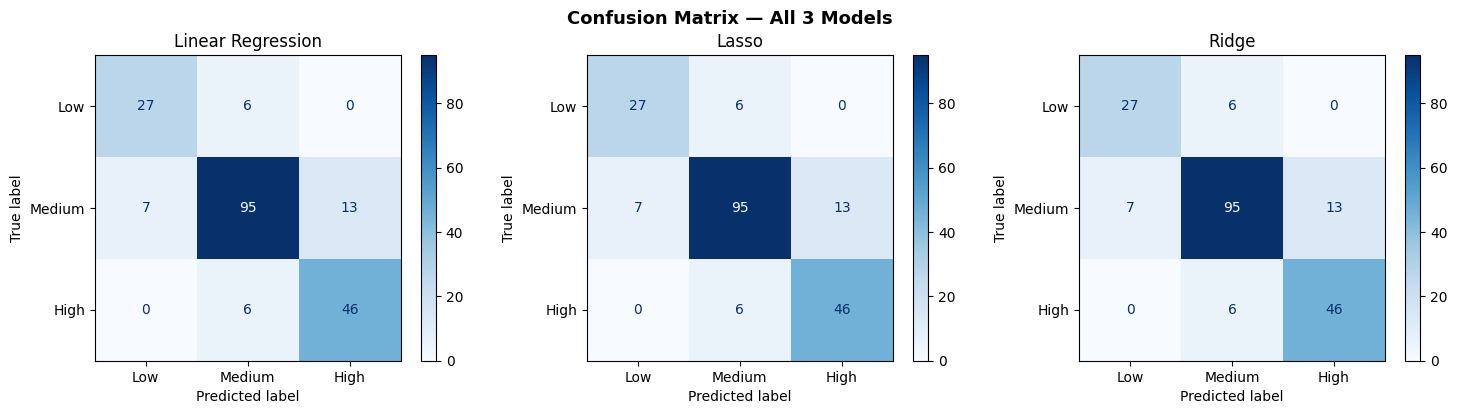

In [92]:
# CONFUSION MATRIX
labels = ['Low', 'Medium', 'High']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrix — All 3 Models', fontsize=13, fontweight='bold')
for ax, cat, title in zip(axes, [lr_cat, las_cat, rid_cat], ['Linear Regression', 'Lasso', 'Ridge']):
    ConfusionMatrixDisplay(confusion_matrix(y_cat, cat, labels=labels), display_labels=labels).plot(ax=ax, cmap='Blues')
    ax.set_title(title)
plt.tight_layout()
plt.show()

In [93]:

import pickle


In [94]:
features = ['Household_Size', 'Seasonal_Index', 'Garden_Area', 'Income_Level', 'Building_Type', 'Avg_Temperature_C', 'Num_Appliances']

save_data = {
    'model': lr, 
    'scaler': scaler, 
    'feature_names': features  
}

with open('model.pkl', 'wb') as f:
    pickle.dump(save_data, f)

In [95]:

import pickle
from sklearn.preprocessing import StandardScaler
features_list = ['Household_Size', 'Seasonal_Index', 'Garden_Area', 'Income_Level', 'Building_Type', 'Avg_Temperature_C', 'Num_Appliances']

X_train_df = pd.DataFrame(x_train, columns=features_list)
final_scaler = StandardScaler()
final_scaler.fit(X_train_df)
save_data = {
    'model': lr, 
    'scaler': final_scaler, 
    'feature_names': features_list
}

with open('model.pkl', 'wb') as f:
    pickle.dump(save_data, f)

print("Model fixed and saved successfully!")

Model fixed and saved successfully!


In [97]:
import pandas as pd
import pickle

# Load the model
with open('model.pkl', 'rb') as f:
    loaded = pickle.load(f)

# Define the columns in the EXACT order they were trained
columns = ['Household_Size', 'Seasonal_Index', 'Garden_Area', 'Income_Level', 'Building_Type', 'Avg_Temperature_C', 'Num_Appliances']

# Create the new house data
new_house = pd.DataFrame([[4, 1.2, 80, 1, 0, 30, 5]], columns=columns)

# FIX: Use .values to avoid the "Feature Names" error
scaled_data = loaded['scaler'].transform(new_house.values)
prediction = loaded['model'].predict(scaled_data[:, :3])

print('Predicted Water Usage:', round(prediction[0], 1), 'Liters/day')

Predicted Water Usage: 80.8 Liters/day
